In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [2]:
%%time

ddir = '~/Repos/SALSA/data/'
_df = pd.read_csv(os.path.join(ddir,'chembl_valid.csv'),usecols=['smiles'])
# print(_df.smiles.str.len().max())
display(_df)

,smiles
0,CCO
1,C
2,CO
3,NCCS
4,NCCN
...,...
1502534,Cc1cn(C2CN(P(=O)(OCC3CN(P(=O)(OCC4CNCC(n5cnc6c...
1502535,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...
1502536,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...
1502537,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...


CPU times: user 949 ms, sys: 124 ms, total: 1.07 s
Wall time: 1.07 s


## 1) Calculate propreties on a sample of ChEMBL.

In [3]:
from tqdm import tqdm
from property_predictors import *

prop_list = get_surface_descriptor_subset()

df = _df.sample(1000,random_state=666).reset_index()
df_props = pd.DataFrame(columns=['smiles'] + prop_list, dtype=object)

for i,smi in tqdm(enumerate(df.smiles),total=len(df)):
    props = surface_predictor(smi)
    named_props = {k:v.item() for k,v in zip(prop_list, props)} 
    df_props.at[i,'smiles'] = smi
    for k,v in named_props.items():
        df_props.at[i,k] = v  
# display(df_props)
df_temp = df_props.set_index('smiles')
props_dict = df_temp.to_dict('index')

100%|██████████| 1000/1000 [00:04<00:00, 209.47it/s]


## 2) Find pair-wise differences of properties.

In [5]:
from itertools import combinations as combo

cols = ['smi_1','smi_2'] + prop_list
df_paired = pd.DataFrame(columns=cols, dtype=object)

ser_list = []
for pair in tqdm(combo(props_dict.items(),2), total=len(props_dict)**2//2):
    
    sm1, sm2 = pair[0][0], pair[1][0]
    
    if sm1==sm2:
        continue
        
    props1, props2 = pair[0][1], pair[1][1]
    diffs = [abs(props1[p] - props2[p]) for p in prop_list]
    
    ser = {k:v for k,v in zip(cols, [sm1, sm2] + diffs)} 
    ser = pd.Series(ser)
    ser_list.append(ser)

100%|█████████▉| 499500/500000 [01:40<00:00, 4983.69it/s]


## 3) Histogram it out.

In [6]:
paired_props = pd.DataFrame(ser_list)
paired_props

,smi_1,smi_2,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,...,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,TPSA
0,O=C(c1ccc(Cl)c(Cl)c1)N1CCC(F)(CNCc2cccc(-c3cnc...,O=C(Nc1ccccc1C(=O)NCc1ccccc1)c1ccccc1Br,5.316789,1.296971,0.000000,7.271935,34.263716,0.000000,0.000000,2.614132,...,0.000000,4.794537,14.358372,0.000000,0.0,25.329058,15.427031,33.566646,5.121750,13.060001
1,O=C(c1ccc(Cl)c(Cl)c1)N1CCC(F)(CNCc2cccc(-c3cnc...,O=C1C2C(CO)COC(C(=O)N2Cc2ccccc2)N1Cc1ccccc1,5.316789,4.390415,0.000000,23.201880,6.126137,20.870695,5.917906,17.766658,...,0.000000,4.794537,14.358372,0.000000,0.0,31.395422,19.204932,25.576702,8.722275,1.180000
2,O=C(c1ccc(Cl)c(Cl)c1)N1CCC(F)(CNCc2cccc(-c3cnc...,CC(CN1CCC(n2nccc2NC(=O)c2ccccc2Cl)CC1)c1ccccc1,0.000000,1.427448,0.000000,11.600940,5.856232,6.544756,0.000000,18.753008,...,0.000000,0.000000,9.676569,5.098682,0.0,31.720999,6.123899,18.883486,0.888731,21.100002
3,O=C(c1ccc(Cl)c(Cl)c1)N1CCC(F)(CNCc2cccc(-c3cnc...,COc1ccc(C=C(C(=O)c2cc(OC)c(OC)c(OC)c2)c2ccc(OC...,23.104388,4.390415,34.497070,23.201880,2.363956,6.544756,0.000000,7.408669,...,0.000000,0.000000,14.358372,0.000000,0.0,17.135513,17.705839,21.817747,20.722748,1.189995
4,O=C(c1ccc(Cl)c(Cl)c1)N1CCC(F)(CNCc2cccc(-c3cnc...,CCCCn1c(SCC(=O)NC2CC2)nc2cc(C(=O)OC)ccc2c1=O,5.559267,4.390415,0.000000,11.439995,5.746021,9.531400,0.000000,14.071451,...,5.969306,9.361637,4.579856,0.000000,0.0,4.161804,7.129732,31.997524,7.392988,19.029999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499495,CC(C)C1NC(=O)CC2NC(=O)C(Cc3ccccc3)NC(=O)C(Cc3c...,COc1cccc(C(=O)Oc2cc(C=CC(=O)c3ccc(OC)c4c3OC(C)...,8.216417,0.000000,28.747559,21.587795,45.019749,41.608868,5.917906,14.295155,...,5.969306,23.972686,4.794537,0.000000,0.0,77.890184,63.058744,30.892107,31.598927,94.310005
499496,CC(C)C1NC(=O)CC2NC(=O)C(Cc3ccccc3)NC(=O)C(Cc3c...,CSCCC1NC(=O)C(CC(C)C)NC(=O)C(CCCNC(=N)N)NC(=O)...,152.205118,0.000000,5.749512,54.937481,377.280899,89.469913,10.818567,123.858814,...,5.969306,106.709309,0.000000,11.761885,0.0,5.355339,174.179190,23.135347,58.145478,959.239960
499497,O=C1CC(C(=O)N2CCC(N3CCC(C(=O)NC4CC4)CC3)CC2)c2...,COc1cccc(C(=O)Oc2cc(C=CC(=O)c3ccc(OC)c4c3OC(C)...,18.367526,0.000000,28.747559,0.000000,26.977139,9.589074,5.917906,21.094742,...,5.969306,9.589075,4.794537,0.000000,0.0,6.056715,22.925659,43.075375,32.101842,10.570000
499498,O=C1CC(C(=O)N2CCC(N3CCC(C(=O)NC4CC4)CC3)CC2)c2...,CSCCC1NC(=O)C(CC(C)C)NC(=O)C(CCCNC(=N)N)NC(=O)...,178.789062,0.000000,5.749512,76.525276,395.323509,121.489707,10.818567,88.468918,...,5.969306,121.092920,0.000000,11.761885,0.0,66.478130,134.046104,10.952080,58.648393,1064.119965


In [7]:
df_SlogP_VSA1 = paired_props[['SlogP_VSA1']]
df_SlogP_VSA1

,SlogP_VSA1
0,5.316789
1,5.316789
2,0.000000
3,23.104388
4,5.559267
...,...
499495,8.216417
499496,152.205118
499497,18.367526
499498,178.789062


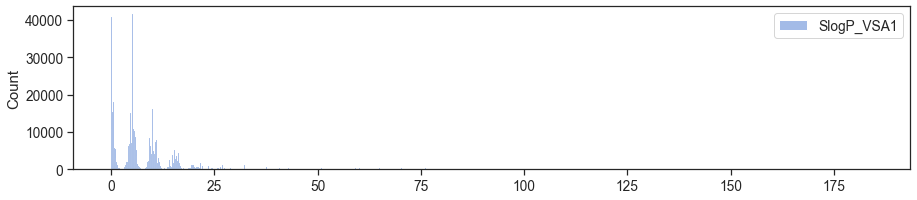

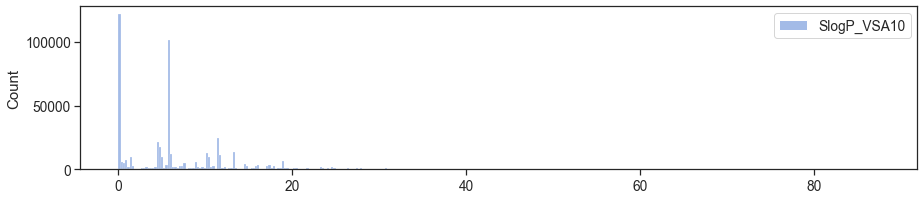

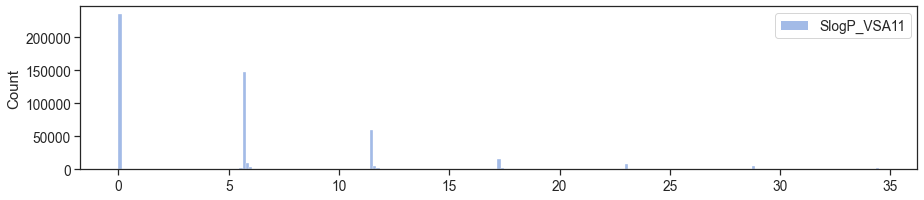

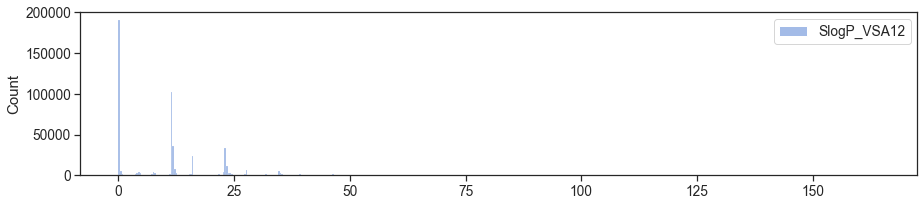

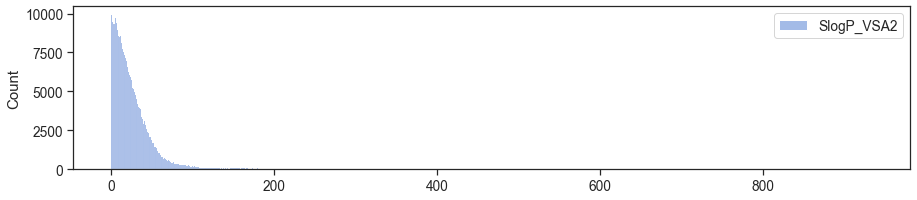

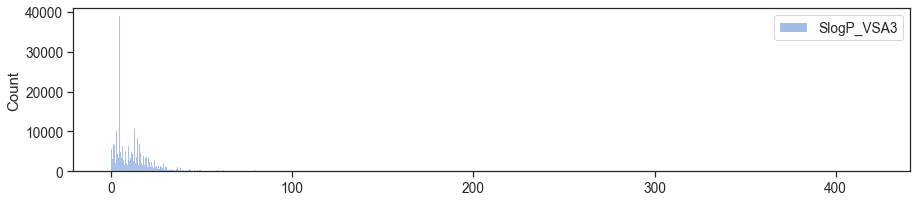

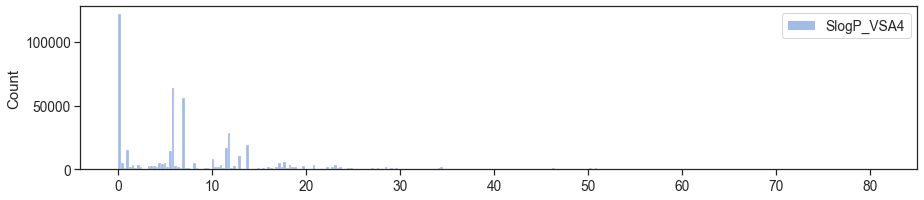

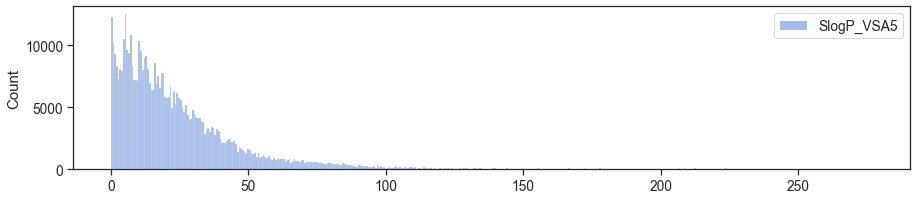

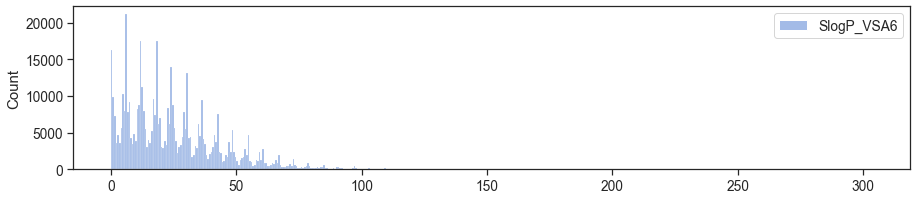

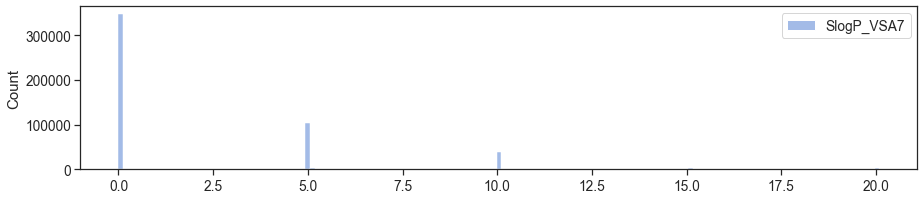

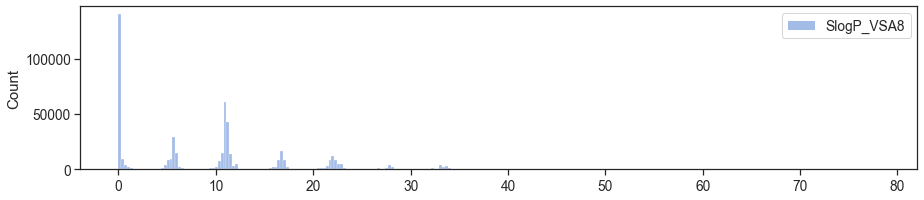

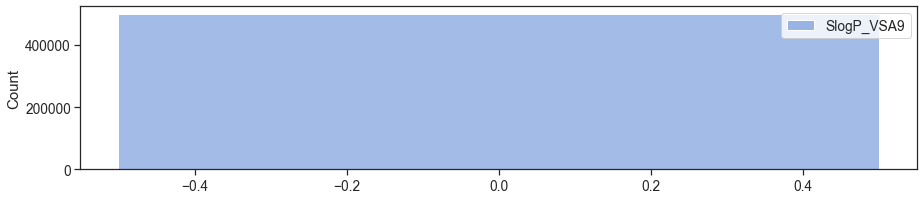

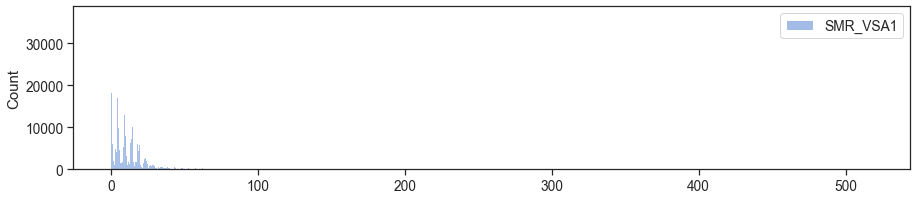

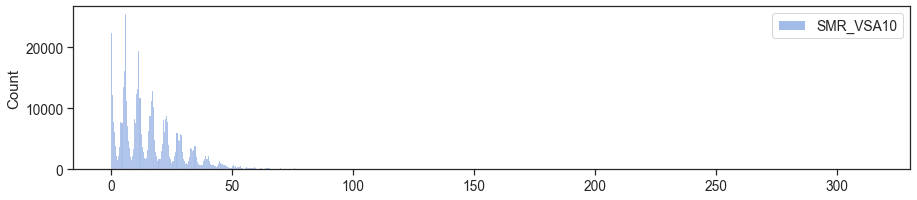

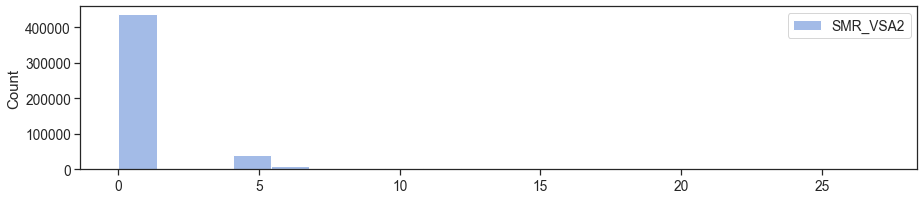

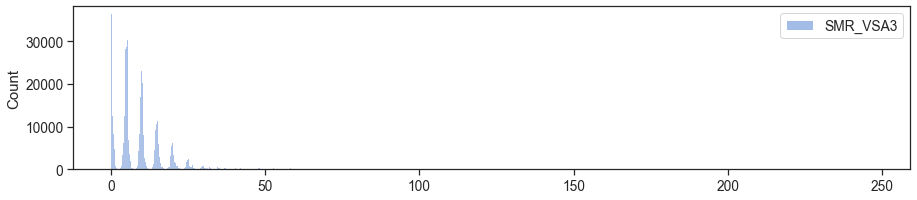

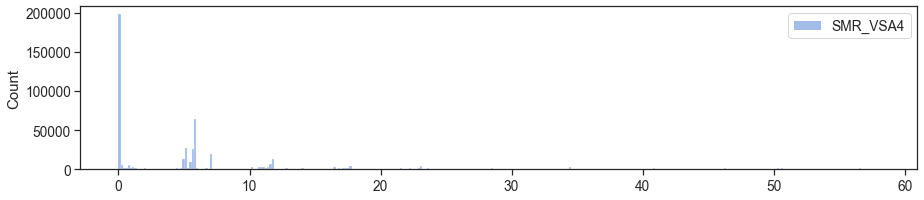

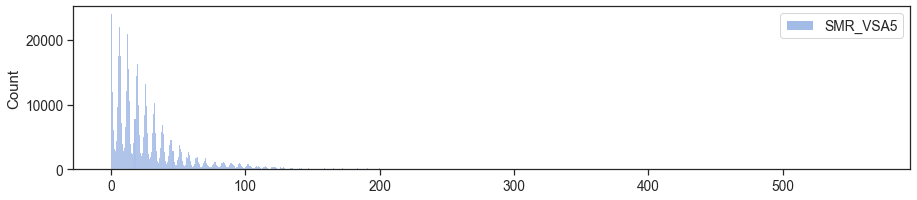

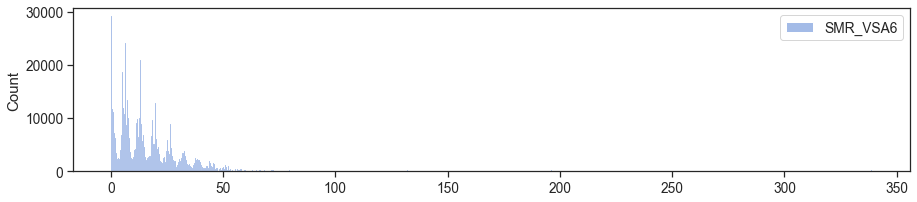

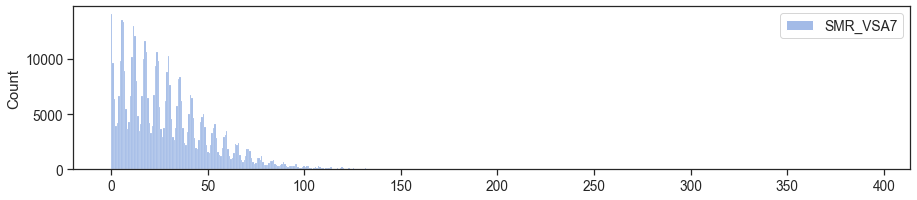

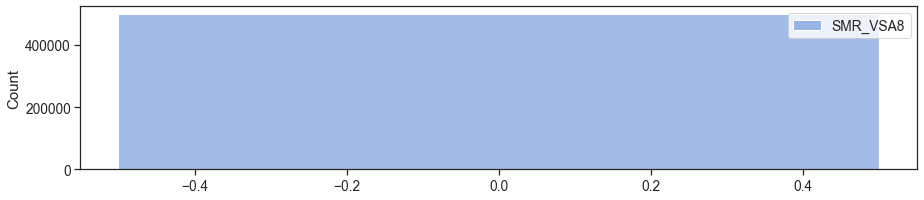

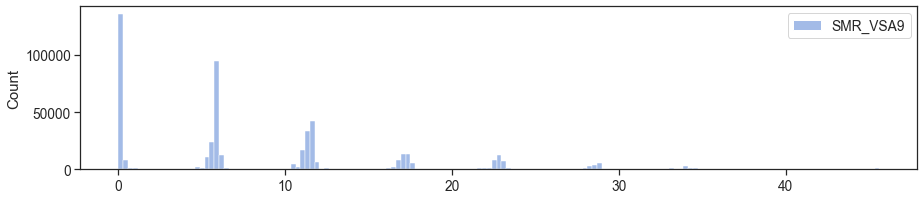

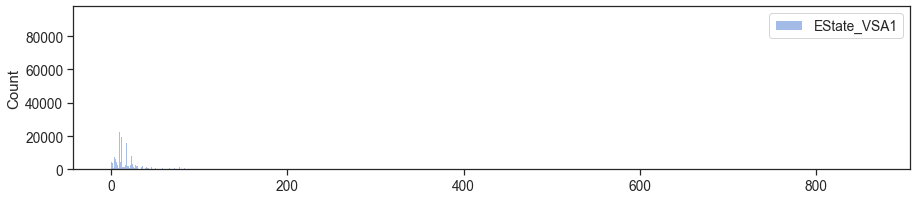

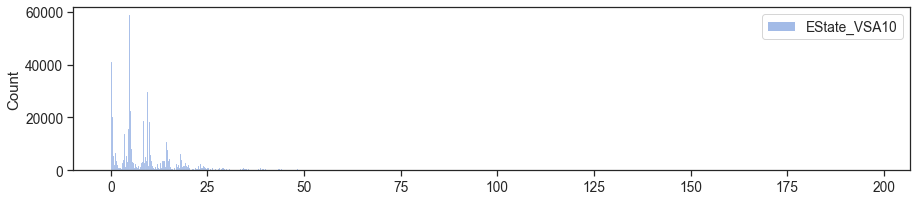

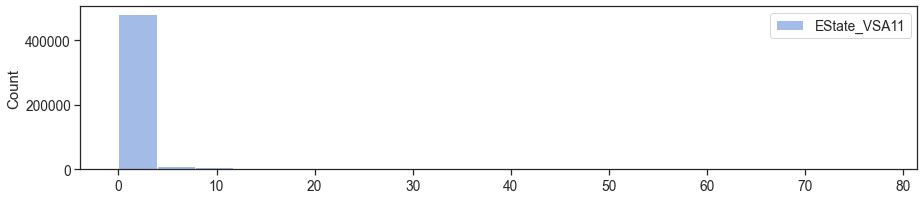

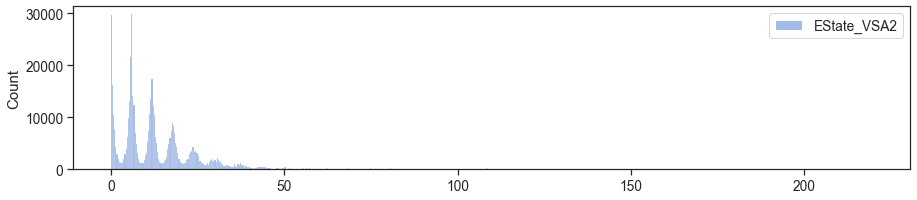

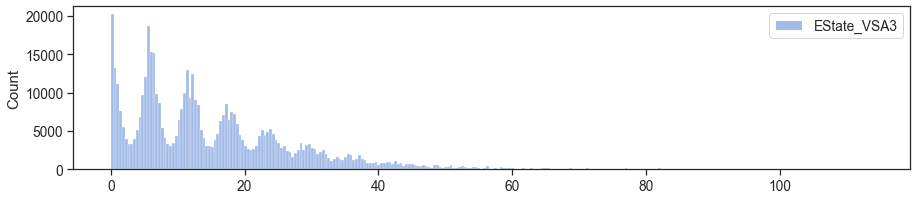

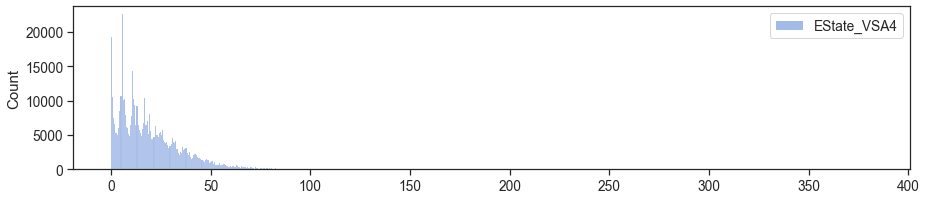

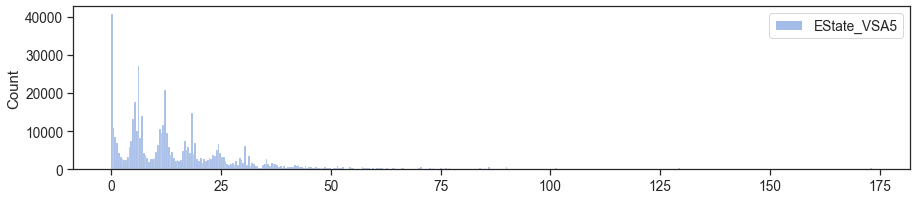

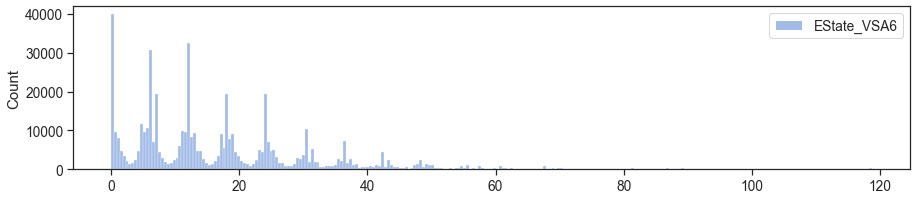

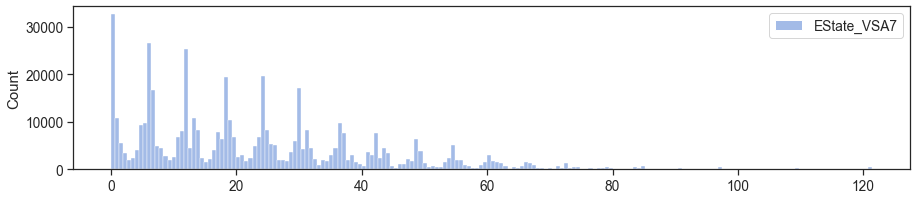

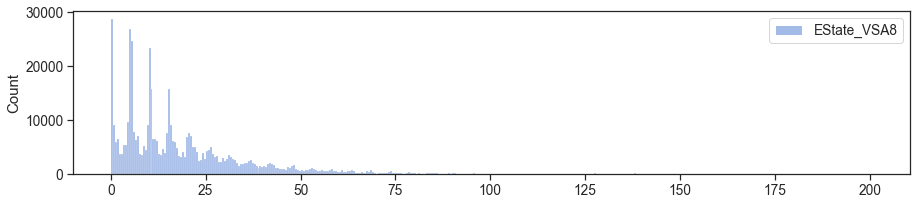

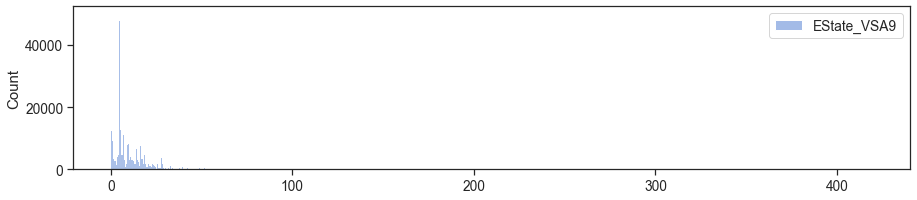

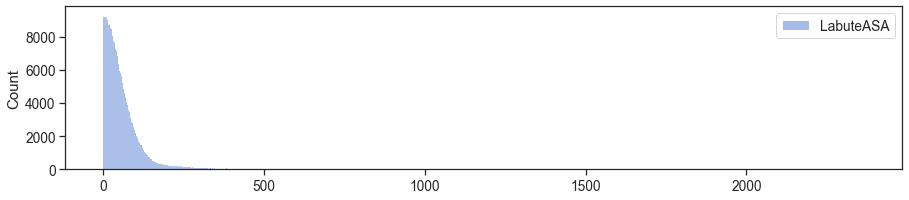

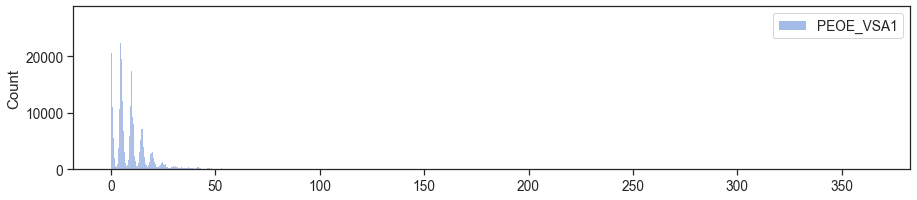

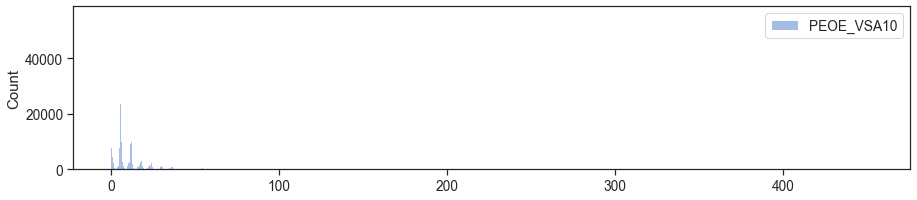

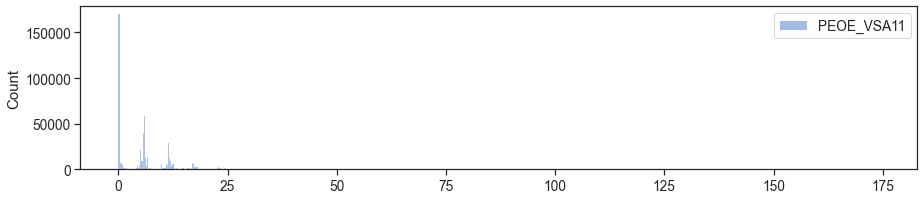

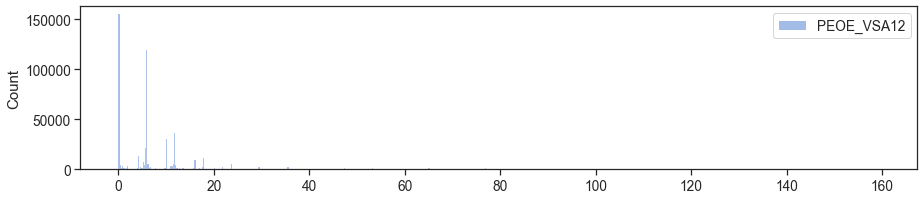

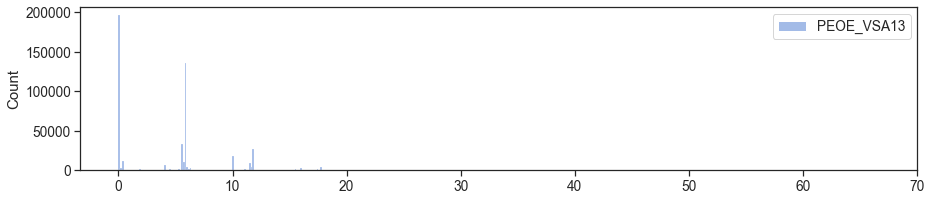

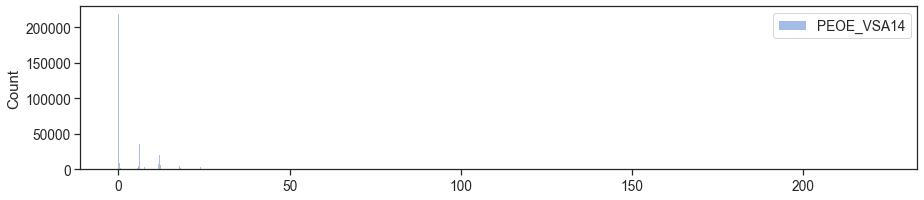

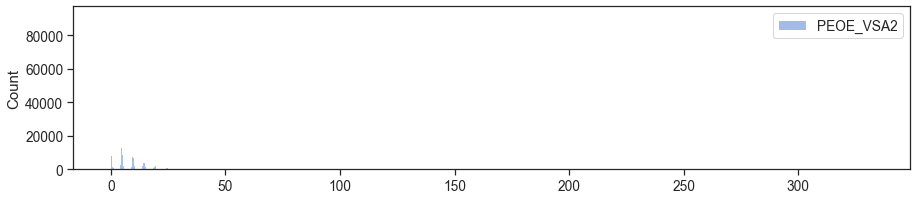

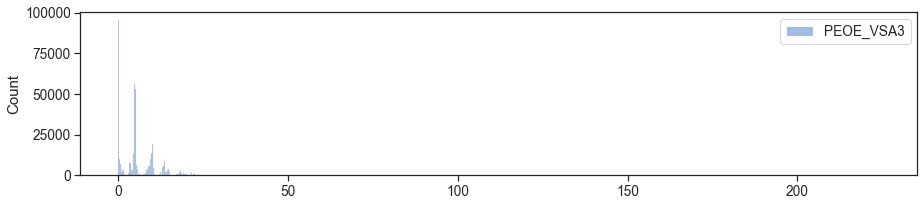

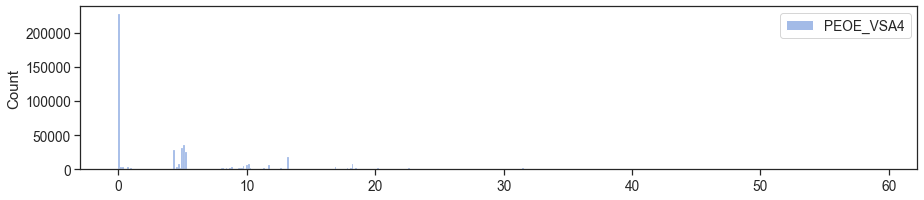

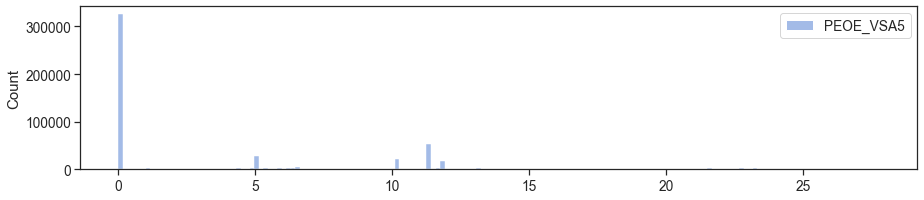

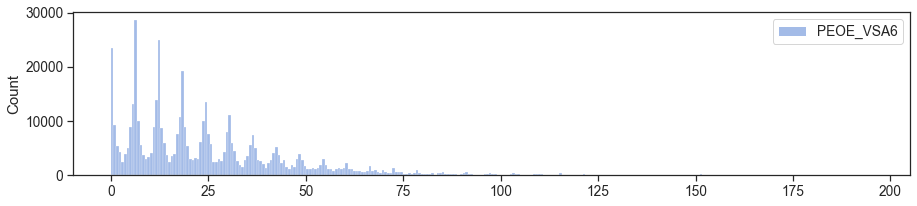

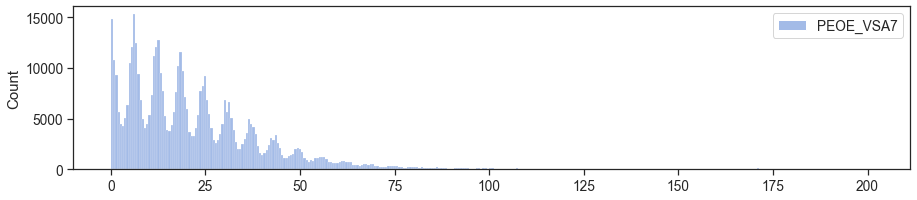

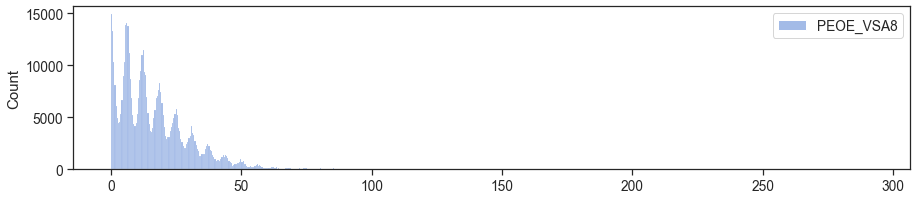

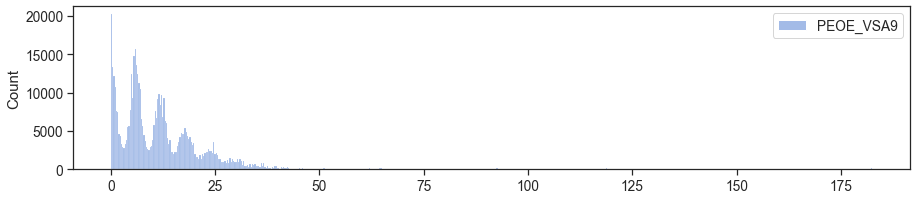

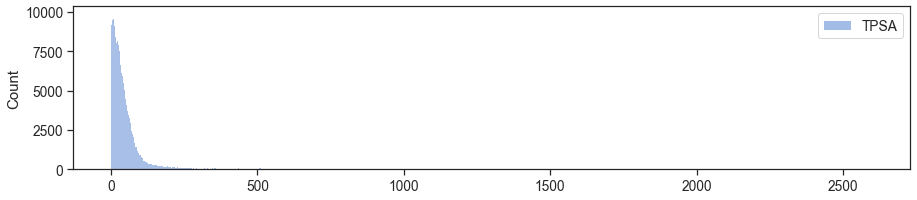

In [15]:
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

for p in prop_list:
    df_prop = paired_props[[p]]
    plt.figure(figsize=(15,3))
    sns.histplot(df_prop)
    plt.show()

In [14]:
len(prop_list)

49